# import

In [ ]:
import pandas as pd
import numpy as np
import cv2 as cv
from pathlib import Path 
import seaborn as sns
import matplotlib.pyplot as plt
from StatTools.generators.ndfnoise_generator import ndfnoise
from tqdm import tqdm
import plotly.express as px
from synth import 

In [60]:
def draw_traj(trajectories, frame_shape:tuple, thickness:int):
    ants_num = trajectories.shape[1]
    bgs = [np.zeros(shape=frame_shape, dtype=np.uint8) for _ in range(ants_num)]
    trajs = []
    for ant in range(ants_num):
        trajs.append(np.array([np.array(traj) for traj in trajectories[:, ant]]))
    for ant, bg in zip(trajs, bgs):
        cv.polylines(bg, [ant], isClosed=False, color=(255), thickness=thickness)
    
    return bgs


def calc_iou(tracks, thickness,  frame_shape):
    bgs = draw_traj(tracks, frame_shape=frame_shape, thickness = thickness)
    bgs_arr_bool = np.stack(bgs).astype(np.bool)
    union = bgs_arr_bool.sum(axis=0)
    union_mask = union.astype(np.bool)
    atleast_two_track_intersection = union - union_mask
    iou = atleast_two_track_intersection.sum() / union.sum()
    return iou, atleast_two_track_intersection, union


def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):
    

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.round().cumsum(axis=0).astype(np.int32)
    y = dy.round().cumsum(axis=0).astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(margin, frame_shape[1] - margin, (ants_num,))
        start_y = np.random.randint(margin, frame_shape[0] - margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

# debug

In [ ]:
husrt_list = [0.3, 0.5, 0.8, 1.0]
result = []
for hurst in husrt_list:
    config = {
    'frame_num' : 1000,
    'frame_shape' : (500, 500),
    'margin': 50,
    'hurst_move': hurst,
    'hurst_species': 0.5,
    'ants_num' : 1000,
    'start_point' : None
    }

    trajectories = gen_traj(**config)
    thickness = 10
    frame_thresholds = np.exp(np.arange(np.log(10), np.log(config['frame_num']), 0.6)).astype(np.int32)
   
    for frame in frame_thresholds:
        track_slice = trajectories[:frame]
        total_l1_path = np.sum(np.abs(np.diff(track_slice, axis=0)), axis=None)
        iou, _, _  = calc_iou(track_slice, thickness, config['frame_shape'])

        result.append({'hurst_species':hurst,
                        'length':total_l1_path,
                        'frame_threshold':frame,
                        'iou': iou,
                    })
            
            

df = pd.DataFrame(result)

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning:

divide by zero encountered in power

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:55: RuntimeWarning:

invalid value encountered in multiply

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:55: RuntimeWarning:

divide by zero encountered in power



In [95]:
# import plotly.graph_objects as go
# fig = go.Figure()
px.line(df, x='length', y='iou', color='hurst_species', log_x=True).show()
px.line(df, x='frame_threshold', y='iou', color='hurst_species', log_x=True).show()

# synth monte-carlo


In [98]:
frame_num = 2000
result = []
seed_list = np.arange(10)
hurst_list = [0.8, 0.9, 1.0, 1.1, 1.2]
thickness_list = [5, 10, 15, 20]
frame_thresholds = np.exp(np.arange(np.log(10), np.log(frame_num), 0.6)).astype(np.int32)
pbar = tqdm(total=len(seed_list)*len(hurst_list)*len(frame_thresholds)*len(thickness_list))
for seed in seed_list:
    np.random.seed(seed)
    for hurst_move in hurst_list:
        for thickness in thickness_list:

            config = {
            'frame_num' : frame_num,
            'frame_shape' : (500, 500),
            'margin': 50,
            'hurst_move': hurst_move,
            'hurst_species': 0.8,
            'ants_num' : 1000,
            'start_point' : None
            }
            
            trajectories = gen_traj(**config)

            for frame in frame_thresholds:
                track_slice = trajectories[:frame]
                iou, _, _  = calc_iou(track_slice, thickness, config['frame_shape'])
                total_l1_path = np.sum(np.abs(np.diff(track_slice, axis=0)), axis=None)
                total_l2_path = np.sum(np.sqrt(np.sum(np.diff(track_slice, axis=0)**2, axis=2)), axis=None)
                result.append({
                    'seed':seed,
                    'hurst_move':hurst_move,
                    'thickness':thickness,
                    'total_l1_path':total_l1_path,
                    'total_l2_path':total_l2_path,
                    'frame_threshold': frame,
                    'iou': iou
                    })
                
                pbar.update(1)      

df = pd.DataFrame(result)

  0%|          | 0/1800 [00:00<?, ?it/s]

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning:

divide by zero encountered in power

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:55: RuntimeWarning:

divide by zero encountered in power

100%|██████████| 1800/1800 [06:31<00:00,  3.00it/s]

In [116]:
df.to_pickle('montecarlo_hurst_thickness_iou_eval_total_length.pkl')

In [101]:
df_median = df.groupby(['hurst_move', 'thickness', 'total_l1_path'])['iou'].median().reset_index()

In [114]:
px.scatter(df[df.thickness==10], x='total_l1_path', y='iou', color='hurst_move', height=500, width=1500, log_x=True)
# fig1.write_html('thickness_hurst.html')

Text(0, 0.5, 'IoU')

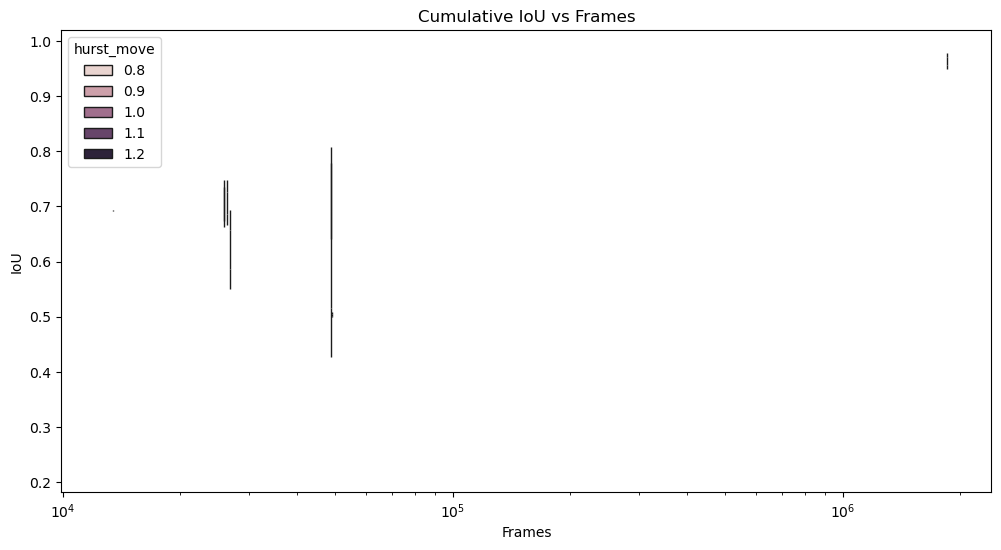

In [115]:
plt.figure(figsize=(12, 6))
# df = pd.read_pickle('montecarlo_hurst_thickness_iou_eval.pkl')
sns.boxplot(df, x='total_l1_path', y='iou', hue='hurst_move', native_scale=True)
plt.xscale('log')
plt.title('Cumulative IoU vs Frames')
plt.xlabel('Frames')
plt.ylabel('IoU')

# long eval

In [11]:
long_traj = pd.read_csv('gen_ants_gt.csv')

In [12]:
x_wide = long_traj.pivot(columns='ant_id', index='frame', values='x')
y_wide = long_traj.pivot(columns='ant_id', index='frame', values='y')
trajectories = np.stack([x_wide.values, y_wide.values], axis=-1)

In [16]:
_result = [] 
for thickness in [5, 10, 15, 20]:
    lens = np.exp(np.arange(np.log(10), np.log(trajectories.shape[0]), 0.4)).astype(np.int32)

    for length in lens:
        track_slice = trajectories[:length]
        iou, _, _  = calc_iou(track_slice, thickness, (500, 500))

        _result.append({'thickness':thickness,
                        'length':length,
                        'iou': iou,
                    })

In [18]:
px.line(_result, x='length', y='iou', color='thickness', height=500, width=1000, log_x=True)